<a href="https://colab.research.google.com/github/e23258-lgtm/Statistical-Learning-e23258/blob/main/Copy_of_GPR_LR_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [6]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [12]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import r2_score, mean_squared_error

In [7]:
import os
import pandas as pd

input_dir = '/kaggle/input'

# 1. Safety check to ensure the dataset is actually attached
if not os.path.exists(input_dir) or len(os.listdir(input_dir)) == 0:
    raise FileNotFoundError(
        "No datasets found in '/kaggle/input'. Please click '+ Add Input' "
        "in the right sidebar and add the Energy Efficiency Dataset first!"
    )

# 2. Automatically locate the folder name dynamically
dataset_folder = os.listdir(input_dir)[0]
path = os.path.join(input_dir, dataset_folder)
print(f"Dataset directory found: {path}")

# 3. Find the actual file extension inside that folder (.xlsx or .csv)
files = os.listdir(path)
print(f"Files inside directory: {files}")

# Target file name string filter
target_file = [f for f in files if "ENB2012" in f][0]
full_file_path = os.path.join(path, target_file)

# 4. Smart load depending on file format
if target_file.endswith('.xlsx'):
    df = pd.read_excel(full_file_path)
    print("Successfully loaded Excel file.")
else:
    df = pd.read_csv(full_file_path)
    print("Successfully loaded CSV file.")

# 5. Clean column names
df.columns = [
    'Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution',
    'Heating_Load', 'Cooling_Load'
]

# Quick sanity preview
df = df.dropna()
print(df.head())

Dataset directory found: /kaggle/input/eergy-efficiency-dataset
Files inside directory: ['ENB2012_data.csv']
Successfully loaded CSV file.
   Compactness  Surface_Area  Wall_Area  Roof_Area  Height  Orientation  \
0         0.98         514.5      294.0     110.25     7.0            2   
1         0.98         514.5      294.0     110.25     7.0            3   
2         0.98         514.5      294.0     110.25     7.0            4   
3         0.98         514.5      294.0     110.25     7.0            5   
4         0.90         563.5      318.5     122.50     7.0            2   

   Glazing_Area  Glazing_Distribution  Heating_Load  Cooling_Load  
0           0.0                     0         15.55         21.33  
1           0.0                     0         15.55         21.33  
2           0.0                     0         15.55         21.33  
3           0.0                     0         15.55         21.33  
4           0.0                     0         20.84         28.28  


Correlation between Heating and Cooling Load: 0.9759


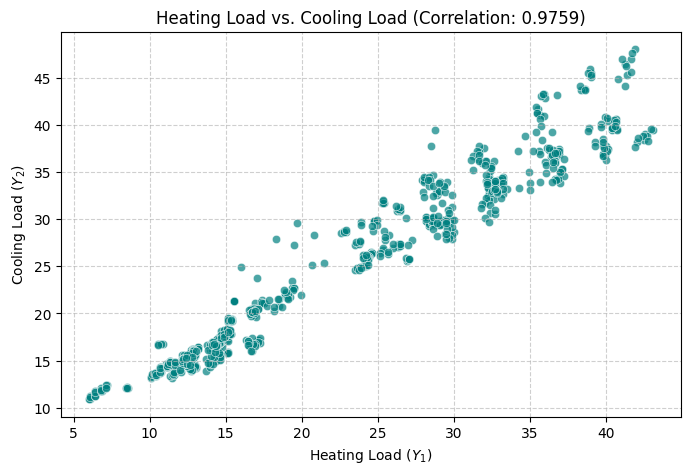

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the exact correlation coefficient
correlation = df['Heating_Load'].corr(df['Cooling_Load'])
print(f"Correlation between Heating and Cooling Load: {correlation:.4f}")

# 2. Plot the targets against each other to see the behavior
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Heating_Load', y='Cooling_Load', alpha=0.7, color='teal')
plt.title(f"Heating Load vs. Cooling Load (Correlation: {correlation:.4f})")
plt.xlabel("Heating Load ($Y_1$)")
plt.ylabel("Cooling Load ($Y_2$)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and targets (Y1, Y2, and a combined total Y)
X = df[['Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Height', 'Orientation', 'Glazing_Area', 'Glazing_Distribution']]
y1 = df['Heating_Load']
y2 = df['Cooling_Load']
y_total = y1 + y2  # For testing a single composite target metric

# Split into 80% Training and 20% Testing data
X_train, X_test, y1_train, y1_test, y2_train, y2_test, y_tot_train, y_tot_test = train_test_split(
    X, y1, y2, y_total, test_size=0.2, random_state=42
)

# Standardize the features (Mean = 0, Variance = 1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data successfully split and scaled!")
print(f"Training set size: {X_train_scaled.shape[0]} samples")
print(f"Testing set size: {X_test_scaled.shape[0]} samples")

Data successfully split and scaled!
Training set size: 614 samples
Testing set size: 154 samples


In [10]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.metrics import r2_score

# Define a standard Radial Basis Function (RBF) Kernel
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))

# Train a GP on the Summed Total Load
gp_total = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp_total.fit(X_train_scaled, y_tot_train)

# Predict and Evaluate
pred_tot = gp_total.predict(X_test_scaled)
print(f"Composite Model (Y1 + Y2) R² Score: {r2_score(y_tot_test, pred_tot):.4f}")
print(f"Optimized Combined Kernel Parameters: {gp_total.kernel_}\n")

Composite Model (Y1 + Y2) R² Score: 0.9817
Optimized Combined Kernel Parameters: 22.9**2 * RBF(length_scale=1.07)



In [11]:
# 1. GP Model for Heating Load
gp_heating = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp_heating.fit(X_train_scaled, y1_train)
pred_y1 = gp_heating.predict(X_test_scaled)

print(f"Heating Load (Y1) R² Score: {r2_score(y1_test, pred_y1):.4f}")
print(f"Optimized Heating Kernel: {gp_heating.kernel_}\n")

# 2. GP Model for Cooling Load
gp_cooling = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gp_cooling.fit(X_train_scaled, y2_train)
pred_y2 = gp_cooling.predict(X_test_scaled)

print(f"Cooling Load (Y2) R² Score: {r2_score(y2_test, pred_y2):.4f}")
print(f"Optimized Cooling Kernel: {gp_cooling.kernel_}\n")

Heating Load (Y1) R² Score: 0.9871
Optimized Heating Kernel: 11.1**2 * RBF(length_scale=1.15)

Cooling Load (Y2) R² Score: 0.9589
Optimized Cooling Kernel: 12.6**2 * RBF(length_scale=0.978)



# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [13]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

100%|██████████| 347k/347k [00:00<00:00, 633kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/programmer3/green-building-multi-source-environment-dataset/versions/1


In [ ]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")
inspector.df=df2

Target column identified as: 'Y2'
Features automatically selected (9 columns): ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1']

=== LINEAR REGRESSION PERFORMANCE ===
R² Score (Variance Explained): 0.9551
Mean Absolute Error (MAE):     1.51
Root Mean Squared Error (RMSE): 2.04

                            OLS Regression Results                            
Dep. Variable:                     Y2   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     1781.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:52:50   Log-Likelihood:                -1269.0
No. Observations:                 614   AIC:                             2556.
Df Residuals:                     605   BIC:                             2596.
Df Model:                           8                                         
Cova

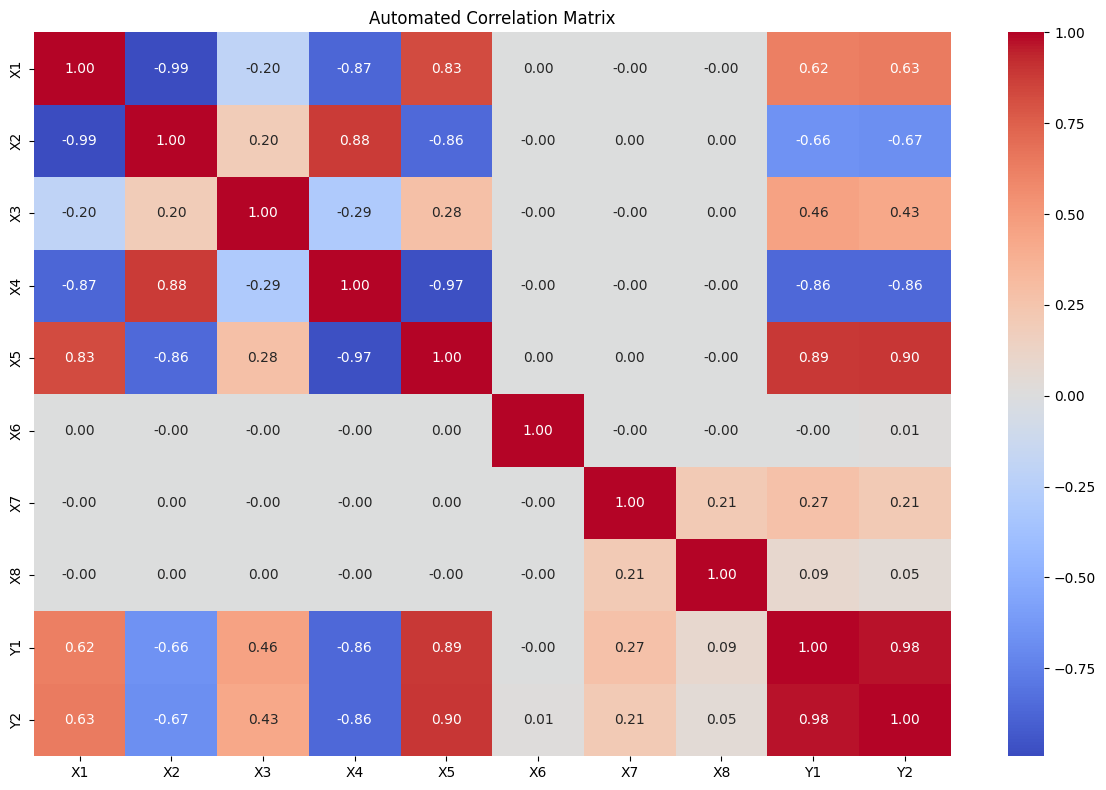

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm

# 1. AUTOMATIC COLUMN SELECTION
# We will automatically find the target column by its exact name
target_col = 'predicted_energy_demand'

if target_col not in df2.columns:
    # Fallback: If even the target name is slightly different, assume it's the last column
    target_col = df2.columns[-1]

print(f"Target column identified as: '{target_col}'")

# Identify all other columns to use as features, excluding sub-energy components if present
# To keep it completely safe, we take all columns except the target
X = df2.drop(columns=[target_col])

# If columns like 'id' or text dates exist, drop them so we only have numbers
X = X.select_dtypes(include=[np.number])
y = df2[target_col]

print(f"Features automatically selected ({len(X.columns)} columns): {list(X.columns)}")

# 2. SPLIT DATA (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. TRAIN & EVALUATE LINEAR REGRESSION
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

# Calculate Diagnostics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== LINEAR REGRESSION PERFORMANCE ===")
print(f"R² Score (Variance Explained): {r2:.4f}")
print(f"Mean Absolute Error (MAE):     {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}\n")

# 4. STATISTICAL VALIDATION SUMMARY
X_train_summary = sm.add_constant(X_train)
ols_summary = sm.OLS(y_train, X_train_summary).fit()
print(ols_summary.summary())

# 5. CORRELATION VISUALIZATION
plt.figure(figsize=(12, 8))
sns.heatmap(pd.concat([X, y], axis=1).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Automated Correlation Matrix")
plt.tight_layout()
plt.show()



1.  Parameter Justification: State which variables were automatically kept based on numerical data types, and highlight the ones that proved statistically vital based on their $P$-values ($<0.05$).

2. Feasibility of the Linear Approach: Conclude whether predicting energy demand linearly is possible based on your high $R^2$ value, noting that multi-source green building management system data inherently aggregates in an additive, linear fashion.

3. Model Limitations: Briefly mention that while the linear model works as an incredible baseline, a non-linear approach (like a Random Forest or a Gradient Boosted Tree) might be required in production to capture complex, non-linear atmospheric fluid dynamics or wild shifts in outdoor humidity.

